In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/content/wine_data.csv',usecols=[1,2,3])
df.columns=['Class label', 'Alcohol', 'Malic acid']
df.head()

,Class label,Alcohol,Malic acid
0,13.20,1.78,2.14
1,13.16,2.36,2.67
2,14.37,1.95,2.50
3,13.24,2.59,2.87
4,14.20,1.76,2.45


<Axes: xlabel='Alcohol', ylabel='Density'>

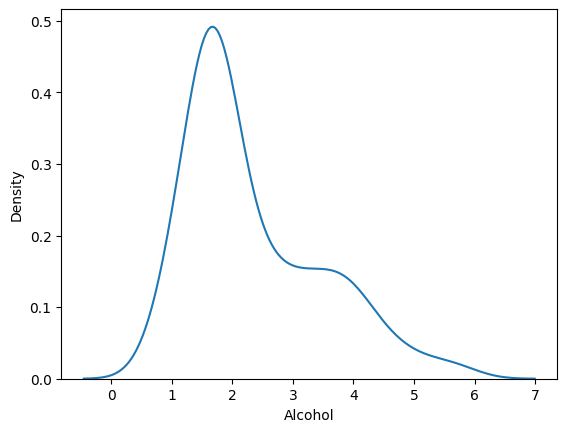

In [6]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

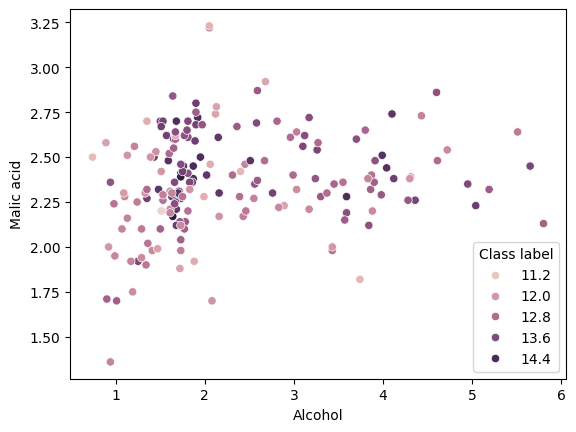

In [10]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Malic acid',
    hue='Class label'
)


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)
X_train.shape,X_test.shape

((123, 2), (54, 2))

In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [20]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [21]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,123.0,123.0
mean,2.3,2.4
std,1.2,0.3
min,0.9,1.4
25%,1.6,2.2
50%,1.8,2.4
75%,3.1,2.6
max,5.8,3.2


In [22]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,123.0,123.0
mean,0.3,0.5
std,0.2,0.2
min,0.0,0.0
25%,0.1,0.5
50%,0.2,0.5
75%,0.4,0.7
max,1.0,1.0


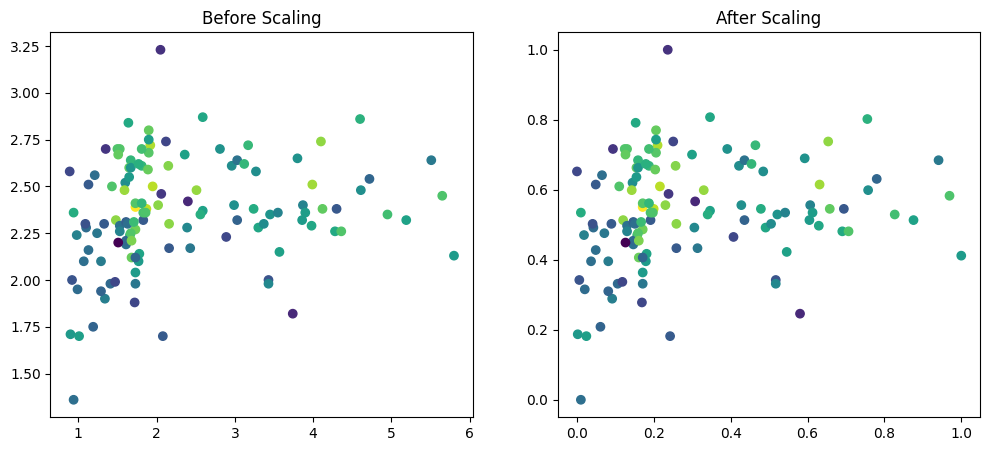

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

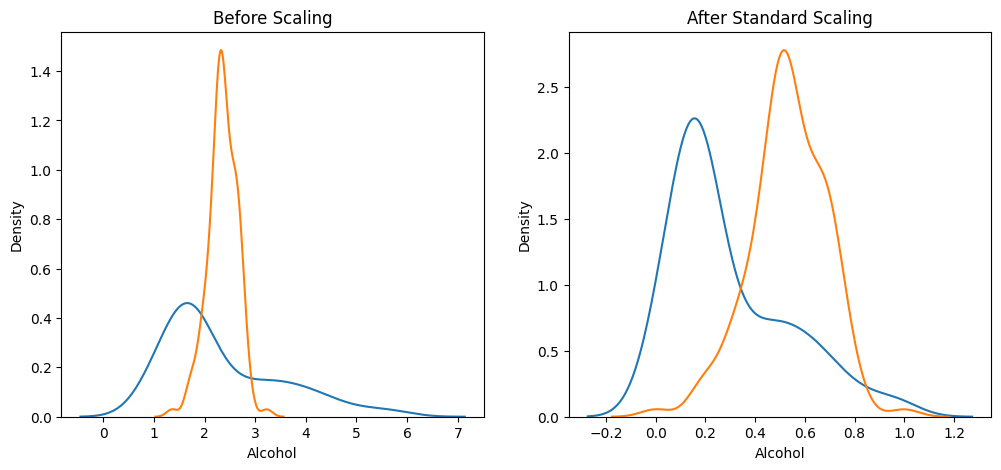

In [25]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2,legend=True)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

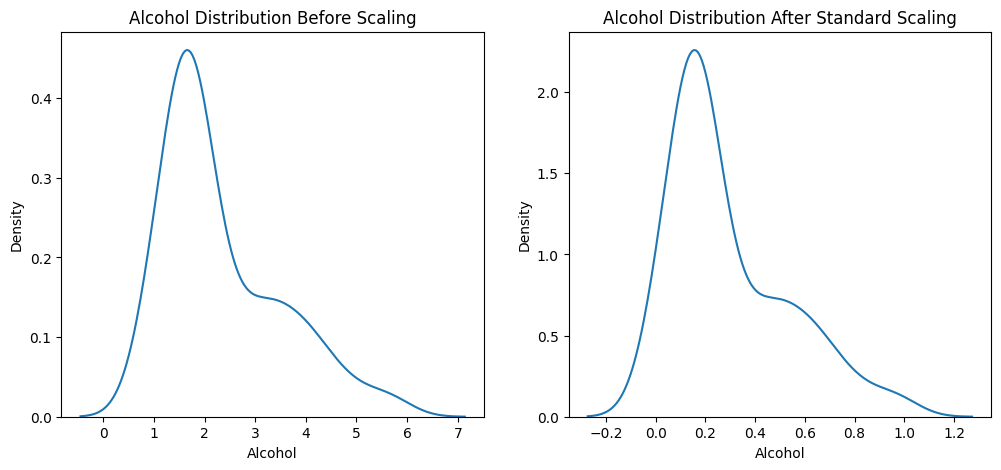

In [26]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()